# Image JEPA - Level 0: The Highest Overview

This notebook shows the **entire training pipeline in ~30 lines of code**.

No deep dives. No explanations of *why*. Just the *what*:

1. Load data
2. Build model
3. Train (SSL + linear probe)
4. Evaluate

In [3]:
import sys
from pathlib import Path

# Add project root to path so imports work from the notebook's location.
# Walk up from the cwd until we find the repo root (marked by pyproject.toml).
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
ROOT = str(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10

from examples.image_jepa.main import ResNet18, ImageSSL, LARS, WarmupCosineScheduler
from examples.image_jepa.dataset import ImageDataset, get_train_transforms, get_val_transforms
from examples.image_jepa.eval import LinearProbe, evaluate_linear_probe
from eb_jepa.losses import VICRegLoss

In [4]:
train_data = ImageDataset(
    CIFAR10(root=f"{ROOT}/examples/my_image_jepa/data", train=True, download=False),
    transform=get_train_transforms(),
    num_crops=2,
)
val_data = CIFAR10(root=f"{ROOT}/examples/my_image_jepa/data", train=False, download=False, transform=get_val_transforms())

train_loader = DataLoader(train_data, batch_size=256, shuffle=True, drop_last=True, num_workers=2)
val_loader   = DataLoader(val_data,   batch_size=256, shuffle=False, num_workers=2)

print(f"Train: {len(train_data)} images | Val: {len(val_data)} images")

Train: 50000 images | Val: 10000 images


In [3]:
sample = train_data[0]
aug_1,aug_2 = sample[0]
label = sample[1]

In [4]:
import matplotlib.pyplot as plt

aug_1.shape

torch.Size([3, 32, 32])

In [5]:
label

6

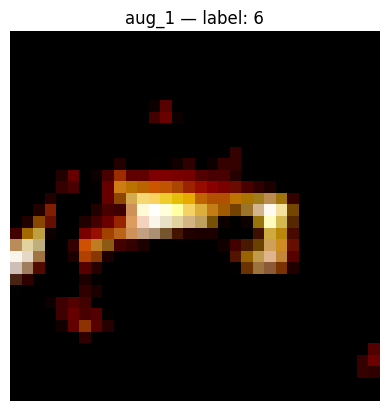

In [6]:
import matplotlib.pyplot as plt

plt.imshow(aug_2.permute(1, 2, 0).clamp(0, 1))
plt.title(f"aug_1 — label: {label}")
plt.axis("off")
plt.show()

## Step 2 - Model

**ResNet-18 backbone** wrapped with a **projector head** (3-layer MLP).

Plus a tiny **linear probe** to track classification accuracy during training.

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ImageSSL(ResNet18(), features_dim=512, proj_hidden_dim=2048, proj_output_dim=2048).to(device)
linear_probe = LinearProbe(feature_dim=512, num_classes=10).to(device)

print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Device: {device}")

Model params: 20,620,352
Device: cpu


## Step 3 - Loss, Optimizer, Scheduler

**VICReg loss**: make the two views' representations *similar* (invariance), while preventing collapse via *variance* and *covariance* regularization.

**LARS optimizer** with cosine warmup schedule.

In [8]:
loss_fn = VICRegLoss(std_coeff=1.0, cov_coeff=80.0)

NUM_EPOCHS = 5  # just a taste - real training uses 300

optimizer = LARS(
    [{"params": model.parameters(), "lr": 0.3},
     {"params": linear_probe.parameters(), "lr": 0.1}],
    weight_decay=1e-4, eta=0.02, clip_lr=True, exclude_bias_n_norm=True, momentum=0.9,
)

scheduler = WarmupCosineScheduler(optimizer, warmup_epochs=2, max_epochs=NUM_EPOCHS, base_lr=0.3)

## Step 4 - Train

Each batch:
1. Feed **view1** and **view2** through the model
2. Compute **VICReg loss** on the projections
3. Compute **linear probe loss** on the frozen features (just for monitoring)
4. Backprop and update

In [ ]:
for epoch in range(NUM_EPOCHS):
    model.train()
    linear_probe.train()
    epoch_loss = 0

    for views, labels in train_loader:
        view1, view2 = views[0].to(device), views[1].to(device)
        labels = labels.to(device)

        # forward pass
        features, z1 = model(view1)
        _,        z2 = model(view2)

        # SSL loss on projections
        ssl_loss = loss_fn(z1, z2)["loss"]

        # linear probe loss on frozen features (just for tracking)
        probe_loss = F.cross_entropy(linear_probe(features.detach()), labels)

        # backward
        total_loss = ssl_loss + probe_loss
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        epoch_loss += ssl_loss.item()

    scheduler.step(epoch)
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch}: loss = {avg_loss:.4f}")

## Step 5 - Evaluate

Freeze the model, run the linear probe on the validation set, report accuracy.

In [ ]:
val_acc, val_loss = evaluate_linear_probe(model, linear_probe, val_loader, device, use_amp=False)
print(f"Validation accuracy: {val_acc:.2f}%  |  loss: {val_loss:.4f}")

---

That's the whole thing. Five steps. Next levels will zoom into each one.